# 08 - Master Analysis Pipeline
**NANO Study | ESD Lab, University of South Carolina**

This notebook consolidates the repository's REDCap, ECG/HRV, imputation, longitudinal modeling, and predictive modeling workflow into a single chronological analysis document.

> HIPAA note: the notebook prefers repo-configured secure inputs when they exist and otherwise falls back to a synthetic cohort so the full workflow remains executable inside the repository.

## Chronological pipeline
1. Load study configuration and resolve secure-data paths.
2. Ingest REDCap-like longitudinal data and processed physiological features.
3. Audit completeness, visit coverage, and missing-data patterns.
4. Demonstrate ECG preprocessing on an exemplar signal.
5. Extract HRV and HDA features using the canonical repo helpers.
6. Merge demographics, physiological features, and trajectory summaries.
7. Perform MICE-style imputation and document missingness assumptions.
8. Produce descriptive figures, trajectory summaries, and inference-ready tables.
9. Train and evaluate predictive models for 36-month ASD-risk classification.
10. Export aggregate artifacts for downstream reports and dashboards.

In [1]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.metrics import roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data_ingestion.redcap_merge import merge_redcap_with_physio
from src.feature_engineering.demographic_features import build_demographic_feature_matrix
from src.feature_engineering.trajectory_features import extract_trajectory_features
from src.imputation.python_imputation import (
    assess_missingness_mechanism,
    document_imputation_assumptions,
    impute_with_mice,
)
from src.models.ml_pipeline import (
    build_pipeline,
    get_feature_importance,
    run_subgroup_analysis,
    train_and_evaluate,
)
from src.models.model_evaluation import (
    bootstrap_ci,
    compare_models,
    compute_classification_metrics,
)
from src.preprocessing.ecg_preprocessing import (
    bandpass_filter,
    detect_rpeaks,
    preprocess_ecg_pipeline,
)
from src.preprocessing.hrv_features import extract_all_hrv_features, identify_hda_phases

print(f"Repo root: {repo_root}")

Repo root: /workspaces/ESD-Lab-USC


In [2]:
EVENT_TO_MONTH = {
    "nicu_admission": 0,
    "month_1": 1,
    "month_2": 2,
    "month_3": 3,
    "month_6": 6,
    "month_9": 9,
    "month_12": 12,
    "month_24": 24,
    "month_36": 36,
}
PHYSIO_EVENTS = {"month_1", "month_2", "month_3", "month_6", "month_9", "month_12", "month_36"}


def load_yaml_with_env(path: Path) -> dict:
    raw = path.read_text(encoding="utf-8")
    for key, value in os.environ.items():
        raw = raw.replace(f"${{{key}}}", value)
    return yaml.safe_load(raw) or {}


def read_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported file format: {path.suffix}")


def simulate_ecg_signal(duration_seconds: int = 180, sampling_rate: int = 1024, heart_rate: int = 140, seed: int = 42):
    rng = np.random.default_rng(seed)
    try:
        import neurokit2 as nk

        signal = nk.ecg_simulate(
            duration=duration_seconds,
            sampling_rate=sampling_rate,
            heart_rate=heart_rate,
            noise=0.02,
            random_state=seed,
        )
    except Exception:
        time_s = np.arange(0, duration_seconds, 1 / sampling_rate)
        signal = 0.03 * np.sin(2 * np.pi * 0.3 * time_s)
        beat_interval = 60 / heart_rate
        for peak_time in np.arange(0.4, duration_seconds, beat_interval):
            signal += np.exp(-0.5 * ((time_s - peak_time) / 0.012) ** 2)
        signal += rng.normal(0, 0.025, size=time_s.shape[0])
        return time_s, signal

    time_s = np.arange(signal.shape[0]) / sampling_rate
    return time_s, signal


def simulate_cohort_data(n_participants: int = 180, seed: int = 42):
    rng = np.random.default_rng(seed)
    groups = np.array(["ASIB", "PT", "TD"])
    group_prob = np.array([0.25, 0.50, 0.25])
    sites = np.array(["USC_Lab", "Prisma_Midlands", "Prisma_Upstate"])
    education_levels = np.array(["hs", "some_college", "bachelors", "graduate"])
    income_levels = np.array(["<20k", "20-40k", "40-60k", "60-80k", ">80k"])
    insurance_levels = np.array(["medicaid", "private"])

    redcap_rows = []
    feature_rows = []

    for pid in range(1, n_participants + 1):
        participant_id = f"NANO-{pid:04d}"
        group = rng.choice(groups, p=group_prob)
        ga = float(np.clip(rng.normal(28.5 if group != "TD" else 39.2, 2.3), 24, 41))
        birth_weight = int(np.clip(rng.normal(1200 if group != "TD" else 3200, 350), 550, 4200))
        sex = rng.choice(["F", "M"])
        site_id = rng.choice(sites, p=[0.40, 0.35, 0.25])
        maternal_education = rng.choice(education_levels, p=[0.20, 0.35, 0.25, 0.20])
        income_bracket = rng.choice(income_levels, p=[0.18, 0.22, 0.24, 0.18, 0.18])
        insurance_type = rng.choice(insurance_levels, p=[0.60, 0.40] if group != "TD" else [0.30, 0.70])
        ivh_grade = int(np.clip(rng.poisson(0.6 if group != "TD" else 0.0), 0, 4))
        bpd_severity = int(np.clip(rng.poisson(0.7 if group != "TD" else 0.0), 0, 3))
        nec = int(rng.random() < (0.12 if group != "TD" else 0.02))
        rop = int(rng.random() < (0.18 if group != "TD" else 0.03))
        sepsis = int(rng.random() < (0.22 if group != "TD" else 0.04))
        withdrawn = int(rng.random() < 0.03)
        enrollment_date = pd.Timestamp("2024-01-01") + pd.to_timedelta(int(rng.integers(0, 420)), unit="D")

        base_rmssd = 28 + (8 if group == "TD" else 3 if group == "ASIB" else 0) + (ga - 28) * 0.6
        base_sdnn = 24 + (6 if group == "TD" else 2 if group == "ASIB" else 0) + (ga - 28) * 0.4
        base_rsa = 1.8 + (0.5 if group == "TD" else 0.2 if group == "ASIB" else 0.0) + (ga - 28) * 0.05

        for event, month in EVENT_TO_MONTH.items():
            visit_keep_prob = 0.98 if month == 0 else max(0.88 - month * 0.004, 0.68)
            if withdrawn and month >= 12:
                visit_keep_prob *= 0.40
            if rng.random() > visit_keep_prob:
                continue

            visit_completed = int(rng.random() < (0.97 if month <= 12 else 0.90))
            ecg_complete = rng.choice([0, 1, 2], p=[0.04, 0.11, 0.85]) if event in PHYSIO_EVENTS else np.nan
            temp_complete = rng.choice([0, 1, 2], p=[0.08, 0.17, 0.75]) if event in PHYSIO_EVENTS else np.nan
            shift = rng.normal(0, 1.2)
            rmssd = base_rmssd + month * 0.35 + shift + rng.normal(0, 4.5)
            sdnn = base_sdnn + month * 0.28 + shift + rng.normal(0, 4.0)
            rsa = base_rsa + month * (0.03 if group != "ASIB" else 0.045) + rng.normal(0, 0.18)
            mean_ibi = 430 + month * 1.5 + rng.normal(0, 22)
            cvnn = np.clip((sdnn / max(mean_ibi, 1)) + rng.normal(0, 0.006), 0.015, 0.25)

            sustained = np.clip(0.42 + month / 120 + (0.06 if group == "TD" else -0.03 if group == "PT" else 0.02) + rng.normal(0, 0.05), 0.10, 0.80)
            orienting = np.clip(0.18 + rng.normal(0, 0.03), 0.05, 0.35)
            termination = np.clip(0.15 + rng.normal(0, 0.03), 0.05, 0.30)
            inattention = float(np.clip(1 - sustained - orienting - termination, 0.05, 0.50))
            total_phase = sustained + orienting + termination + inattention
            sustained, orienting, termination, inattention = [value / total_phase for value in [sustained, orienting, termination, inattention]]

            if rng.random() < (0.04 + month / 250):
                rmssd = np.nan
            if rng.random() < (0.04 + month / 260):
                sdnn = np.nan
            if rng.random() < (0.03 + month / 300):
                rsa = np.nan

            ados_css_total = np.nan
            if event == "month_36":
                if group == "ASIB":
                    ados_css_total = float(np.clip(rng.normal(7.6, 1.1), 1, 10))
                elif group == "PT":
                    ados_css_total = float(np.clip(rng.normal(4.2, 1.2), 1, 10))
                else:
                    ados_css_total = float(np.clip(rng.normal(3.0, 0.9), 1, 10))

            bayley4_cog_composite = np.nan
            if event in {"month_12", "month_36"}:
                bayley4_cog_composite = float(np.clip(rng.normal(90 + (8 if group == "TD" else -5 if group == "ASIB" else 0), 11), 55, 130))

            mchat_total = np.nan
            if event in {"month_9", "month_24"}:
                mchat_total = int(np.clip(rng.normal(2 if group == "TD" else 4 if group == "PT" else 6, 2), 0, 20))

            record_completeness_pct = float(np.clip(93 - month * 0.4 + rng.normal(0, 5), 55, 100))
            qc_status = "Excellent" if record_completeness_pct >= 90 else "Good" if record_completeness_pct >= 80 else "Marginal"

            redcap_rows.append({
                "participant_id": participant_id,
                "record_id": participant_id,
                "event": event,
                "redcap_event_name": event,
                "month": month,
                "group_code": group,
                "group_assignment": group,
                "ga_at_birth_weeks": ga,
                "sex": sex,
                "birth_weight_g": birth_weight,
                "site_id": site_id,
                "maternal_education": maternal_education,
                "income_bracket": income_bracket,
                "insurance_type": insurance_type,
                "ivh_grade": ivh_grade,
                "bpd_severity": bpd_severity,
                "nec": nec,
                "rop": rop,
                "sepsis": sepsis,
                "visit_completed": visit_completed,
                "enrollment_date": enrollment_date,
                "ecg_recording_complete": ecg_complete,
                "temp_recording_complete": temp_complete,
                "double_entry_mismatch": int(rng.random() < 0.02),
                "value_out_of_range": int(rng.random() < 0.03),
                "ecg_transfer_late": int(event in PHYSIO_EVENTS and rng.random() < 0.05),
                "temp_quality_rejected": int(event in PHYSIO_EVENTS and rng.random() < 0.04),
                "open_query": int(rng.random() < 0.03),
                "pi_review_needed": int(rng.random() < 0.04),
                "double_entry_pending": int(rng.random() < 0.05),
                "withdrawn": withdrawn,
                "record_completeness_pct": record_completeness_pct,
                "qc_status": qc_status,
                "bayley4_cog_composite": bayley4_cog_composite,
                "ados2_css_total": ados_css_total,
                "mchat_total": mchat_total,
            })

            if event in PHYSIO_EVENTS and visit_completed == 1:
                n_beats_total = int(rng.integers(280, 360))
                qa_score = float(np.clip(record_completeness_pct + rng.normal(0, 3), 60, 100))
                n_beats_valid = int(round(n_beats_total * qa_score / 100))
                feature_rows.append({
                    "participant_id": participant_id,
                    "event": event,
                    "month": month,
                    "group_code": group,
                    "rmssd": rmssd,
                    "sdnn": sdnn,
                    "rsa_cwt_power": rsa,
                    "td_mean_ibi": mean_ibi,
                    "td_cvnn": cvnn,
                    "pc_sd1": rmssd / np.sqrt(2) if pd.notna(rmssd) else np.nan,
                    "pc_sd2": sdnn * np.sqrt(2) if pd.notna(sdnn) else np.nan,
                    "hda_pct_orienting": orienting,
                    "hda_pct_sustained_attention": sustained,
                    "hda_pct_termination": termination,
                    "hda_pct_inattention": inattention,
                    "qa_score": qa_score,
                    "n_beats_valid": n_beats_valid,
                    "n_beats_total": n_beats_total,
                })

    return pd.DataFrame(redcap_rows), pd.DataFrame(feature_rows)


def standardize_redcap_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rename_map = {}
    if "record_id" in df.columns and "participant_id" not in df.columns:
        rename_map["record_id"] = "participant_id"
    if "redcap_event_name" in df.columns and "event" not in df.columns:
        rename_map["redcap_event_name"] = "event"
    if "group_assignment" in df.columns and "group_code" not in df.columns:
        rename_map["group_assignment"] = "group_code"
    if rename_map:
        df = df.rename(columns=rename_map)

    if "record_id" not in df.columns and "participant_id" in df.columns:
        df["record_id"] = df["participant_id"]
    if "redcap_event_name" not in df.columns and "event" in df.columns:
        df["redcap_event_name"] = df["event"]
    if "group_assignment" not in df.columns and "group_code" in df.columns:
        df["group_assignment"] = df["group_code"]
    if "month" not in df.columns and "event" in df.columns:
        df["month"] = df["event"].map(EVENT_TO_MONTH)
    return df


def standardize_feature_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "redcap_event_name" in df.columns and "event" not in df.columns:
        df = df.rename(columns={"redcap_event_name": "event"})
    if "record_id" in df.columns and "participant_id" not in df.columns:
        df = df.rename(columns={"record_id": "participant_id"})
    if "group_assignment" in df.columns and "group_code" not in df.columns:
        df = df.rename(columns={"group_assignment": "group_code"})
    if "month" not in df.columns and "event" in df.columns:
        df["month"] = df["event"].map(EVENT_TO_MONTH)
    if "rsa_cwt_power" not in df.columns and "rsa" in df.columns:
        df["rsa_cwt_power"] = df["rsa"]
    return df


def load_or_simulate_data():
    paths_cfg = load_yaml_with_env(repo_root / "config" / "paths.yml")
    study_cfg = load_yaml_with_env(repo_root / "config" / "study_parameters.yml")
    processed_cfg = paths_cfg.get("processed", {})
    redcap_path = processed_cfg.get("redcap_latest")
    feature_path = processed_cfg.get("feature_matrix")

    if redcap_path and feature_path and "${" not in str(redcap_path) and "${" not in str(feature_path):
        redcap_path = Path(str(redcap_path))
        feature_path = Path(str(feature_path))
        if redcap_path.exists() and feature_path.exists():
            redcap_df = standardize_redcap_df(read_table(redcap_path))
            feature_df = standardize_feature_df(read_table(feature_path))
            return redcap_df, feature_df, "repo secure data", study_cfg

    redcap_df, feature_df = simulate_cohort_data()
    return standardize_redcap_df(redcap_df), standardize_feature_df(feature_df), "synthetic fallback", study_cfg


def summarize_participant(df: pd.DataFrame) -> pd.Series:
    ordered = df.sort_values("month")
    last_features = ordered[["rmssd", "sdnn", "rsa_cwt_power", "hda_pct_sustained_attention"]].ffill().iloc[-1]
    month_36 = ordered.loc[ordered["event"] == "month_36"]
    ados_series = month_36["ados2_css_total"].dropna()
    ados_value = float(ados_series.iloc[0]) if not ados_series.empty else np.nan

    def first_valid(series: pd.Series):
        valid = series.dropna()
        return valid.iloc[0] if not valid.empty else np.nan

    return pd.Series({
        "group_code": first_valid(ordered["group_code"]),
        "ga_at_birth_weeks": first_valid(ordered["ga_at_birth_weeks"]),
        "birth_weight_g": first_valid(ordered["birth_weight_g"]),
        "morbidity_score": first_valid(ordered["morbidity_score"]),
        "mat_edu_ord": first_valid(ordered["mat_edu_ord"]),
        "income_ord": first_valid(ordered["income_ord"]),
        "insurance_ord": first_valid(ordered["insurance_ord"]),
        "rmssd_last": last_features["rmssd"],
        "sdnn_last": last_features["sdnn"],
        "rsa_last": last_features["rsa_cwt_power"],
        "hda_sustained_last": last_features["hda_pct_sustained_attention"],
        "ados2_css_total": ados_value,
        "asd_risk_flag": float(ados_value >= 7) if pd.notna(ados_value) else np.nan,
    })

## 1. Cohort assembly, REDCap audit, and missingness
The first pass through a longitudinal cohort should answer three questions before modeling starts:

1. Which visits are actually represented by group?
2. Which instruments or derived features show systematic missingness?
3. Is attrition concentrated at later follow-up points in a way that could bias inference?

The next cell loads the analysis tables, merges the REDCap and physiological layers, adds demographic features from the canonical repo helper, and visualizes visit coverage plus core-variable missingness.

2026-06-13 18:41:44 | src.data_ingestion.redcap_merge | INFO | Merging: 1355 REDCap records × 1008 physio records | 180 overlapping participants.
2026-06-13 18:41:44 | src.data_ingestion.redcap_merge | INFO | Merge complete (how='left'): 1355 left + 1008 right → 1355 rows. Rows with no physio match: 347
2026-06-13 18:41:44 | src.feature_engineering.demographic_features | INFO | encode_ga_bins: encoded 1355 GA values.
2026-06-13 18:41:44 | src.feature_engineering.demographic_features | INFO | encode_group_membership: one-hot encoded 1355 rows.
2026-06-13 18:41:44 | src.feature_engineering.demographic_features | INFO | compute_morbidity_score: mean=1.47, range=[0, 6].
2026-06-13 18:41:44 | src.feature_engineering.demographic_features | INFO | encode_ses_indicators: encoded SES for 1355 rows.
2026-06-13 18:41:44 | src.feature_engineering.demographic_features | INFO | build_demographic_feature_matrix: 1355 rows × 8 columns.


Data source: synthetic fallback
REDCap rows: (1355, 36); feature rows: (1008, 18); merged rows: (1355, 61)


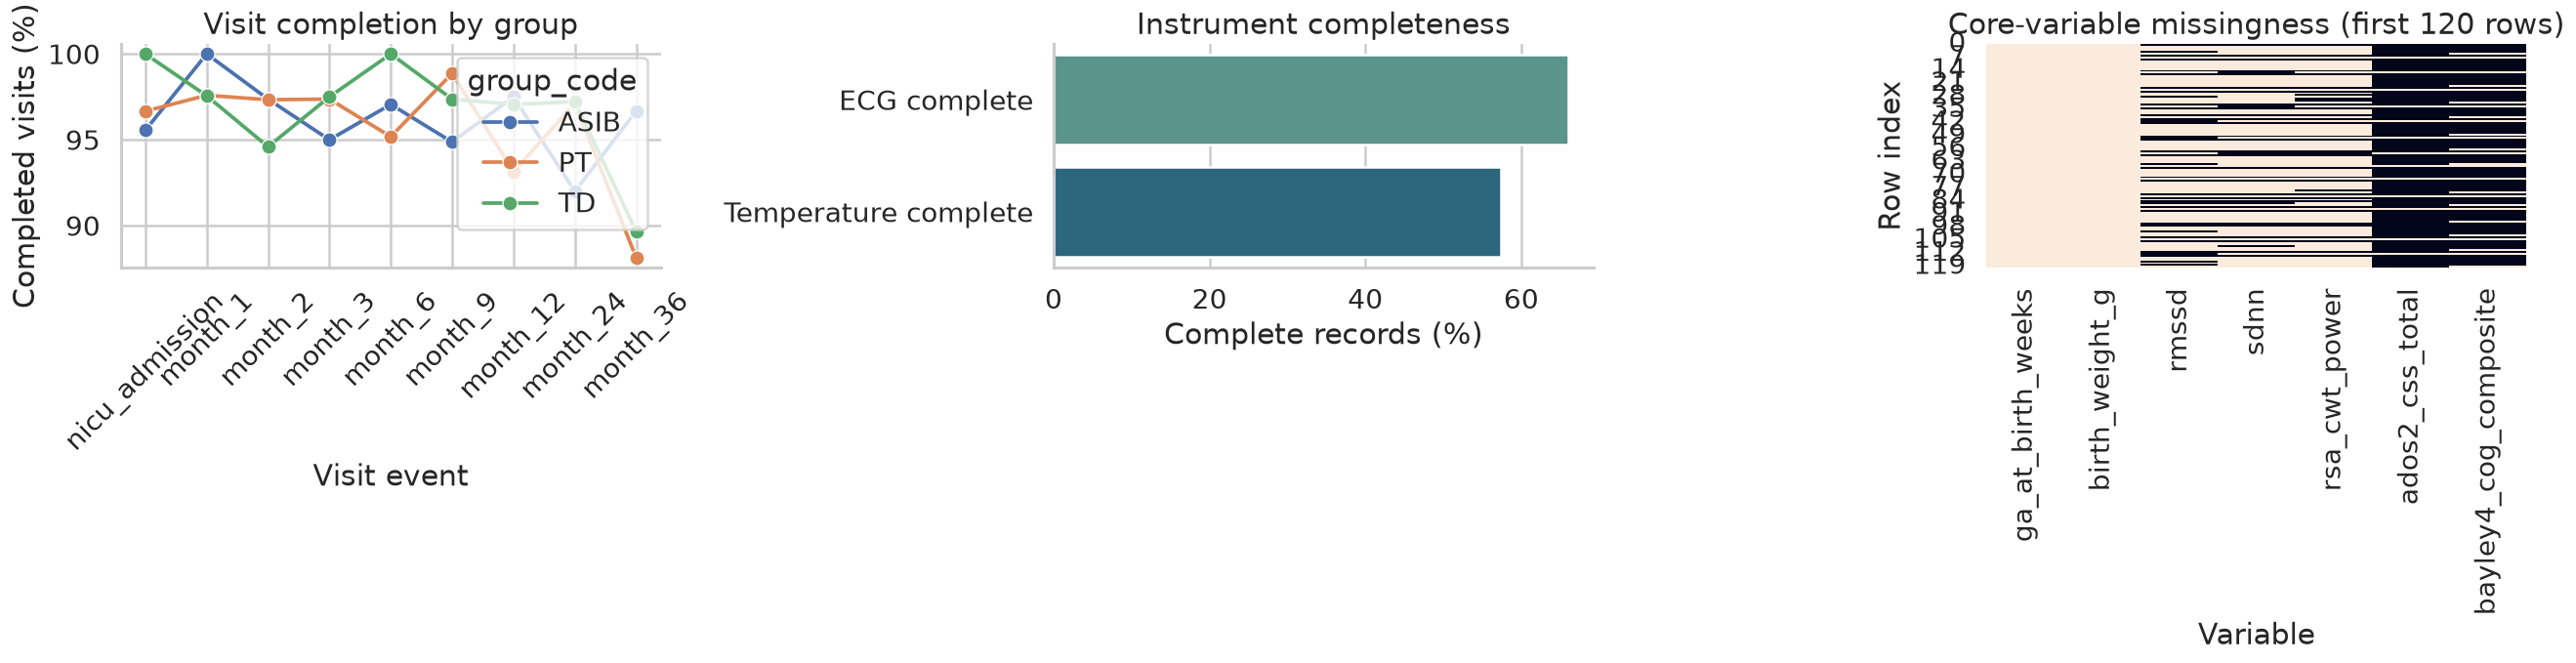

,participant_id,event,group_code,month,rmssd,sdnn,rsa_cwt_power,ados2_css_total
0,NANO-0001,nicu_admission,TD,0,NaN,NaN,NaN,NaN
1,NANO-0001,month_1,TD,1,37.717381,30.368553,2.887509,NaN
2,NANO-0001,month_2,TD,2,44.818126,37.123425,2.943204,NaN
3,NANO-0001,month_3,TD,3,44.513175,36.164332,2.950171,NaN
4,NANO-0001,month_6,TD,6,NaN,31.349974,2.962284,NaN
5,NANO-0001,month_12,TD,12,50.846299,36.421697,2.716633,NaN
6,NANO-0001,month_24,TD,24,NaN,NaN,NaN,NaN
7,NANO-0001,month_36,TD,36,48.594593,38.350459,4.117569,2.99539
8,NANO-0002,nicu_admission,TD,0,NaN,NaN,NaN,NaN
9,NANO-0002,month_1,TD,1,45.074451,29.797719,2.715932,NaN


In [3]:
redcap_df, feature_df, data_source, study_cfg = load_or_simulate_data()
analysis_long = merge_redcap_with_physio(redcap_df, feature_df, how="left")
demo_features = build_demographic_feature_matrix(analysis_long)
analysis_long = pd.concat([analysis_long.reset_index(drop=True), demo_features.reset_index(drop=True)], axis=1)
analysis_long["month"] = analysis_long["month"].fillna(analysis_long["event"].map(EVENT_TO_MONTH))
analysis_long["group_code"] = analysis_long["group_code"].fillna(analysis_long["group_assignment"])
analysis_long["asd_risk_flag"] = (analysis_long["ados2_css_total"].fillna(0) >= 7).astype(int)
analysis_long = analysis_long.sort_values(["participant_id", "month"]).reset_index(drop=True)

print(f"Data source: {data_source}")
print(f"REDCap rows: {redcap_df.shape}; feature rows: {feature_df.shape}; merged rows: {analysis_long.shape}")

visit_completion = (
    analysis_long.groupby(["group_code", "event"])["visit_completed"]
    .mean()
    .reset_index()
    .assign(visit_pct=lambda frame: frame["visit_completed"] * 100)
)
visit_completion["event"] = pd.Categorical(visit_completion["event"], categories=list(EVENT_TO_MONTH.keys()), ordered=True)

instrument_completion = analysis_long[["ecg_recording_complete", "temp_recording_complete"]].apply(
    lambda column: (column == 2).mean() * 100
)
instrument_completion = instrument_completion.rename(index={
    "ecg_recording_complete": "ECG complete",
    "temp_recording_complete": "Temperature complete",
})

heatmap_columns = [
    "ga_at_birth_weeks",
    "birth_weight_g",
    "rmssd",
    "sdnn",
    "rsa_cwt_power",
    "ados2_css_total",
    "bayley4_cog_composite",
]
heatmap_frame = analysis_long[heatmap_columns].head(120)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.lineplot(data=visit_completion, x="event", y="visit_pct", hue="group_code", marker="o", ax=axes[0])
axes[0].set_title("Visit completion by group")
axes[0].set_xlabel("Visit event")
axes[0].set_ylabel("Completed visits (%)")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=instrument_completion.values, y=instrument_completion.index, palette="crest", ax=axes[1])
axes[1].set_title("Instrument completeness")
axes[1].set_xlabel("Complete records (%)")
axes[1].set_ylabel("")

sns.heatmap(heatmap_frame.isna(), cbar=False, cmap="rocket_r", ax=axes[2])
axes[2].set_title("Core-variable missingness (first 120 rows)")
axes[2].set_xlabel("Variable")
axes[2].set_ylabel("Row index")

plt.tight_layout()
plt.show()

analysis_long[["participant_id", "event", "group_code", "month", "rmssd", "sdnn", "rsa_cwt_power", "ados2_css_total"]].head(10)

## 2. Exemplar ECG preprocessing and HRV theory
The repository's canonical signal-processing path lives in `src/preprocessing/ecg_preprocessing.py` and `src/preprocessing/hrv_features.py`. The goal of this section is not to re-implement those functions, but to show what a single raw ECG trace becomes after filtering, R-peak detection, IBI cleaning, and HRV/HDA feature extraction.

Conceptually, the transformation is:

- raw ECG -> filtered signal
- filtered signal -> R-peaks -> inter-beat intervals
- cleaned IBI series -> time-domain HRV, Poincare geometry, RSA
- IBI trajectory -> HDA phase composition

2026-06-13 18:43:10 | nano.audit_trail | INFO | CALL | src.preprocessing.ecg_preprocessing.preprocess_ecg_pipeline | 2026-06-13T18:43:10.476134 | input_rows=N/A
2026-06-13 18:43:10 | src.preprocessing.ecg_preprocessing | INFO | preprocess_ecg_pipeline: input signal length=184320 samples at 1024 Hz.
2026-06-13 18:43:10 | src.preprocessing.ecg_preprocessing | INFO | remove_ecg_artifacts: removed 11 outlier beats (>3.5 SD).
2026-06-13 18:43:10 | src.preprocessing.ecg_preprocessing | INFO | reject_windows: 1/1 windows passed (window_size=300 beats).
2026-06-13 18:43:10 | src.preprocessing.ecg_preprocessing | WARNING | [STEP: preprocess_ecg_pipeline] input=184320 → output=408 (0.2% retained)
2026-06-13 18:43:10 | nano.audit_trail | INFO | RETURN | src.preprocessing.ecg_preprocessing.preprocess_ecg_pipeline | 2026-06-13T18:43:10.559467 | output_rows=408


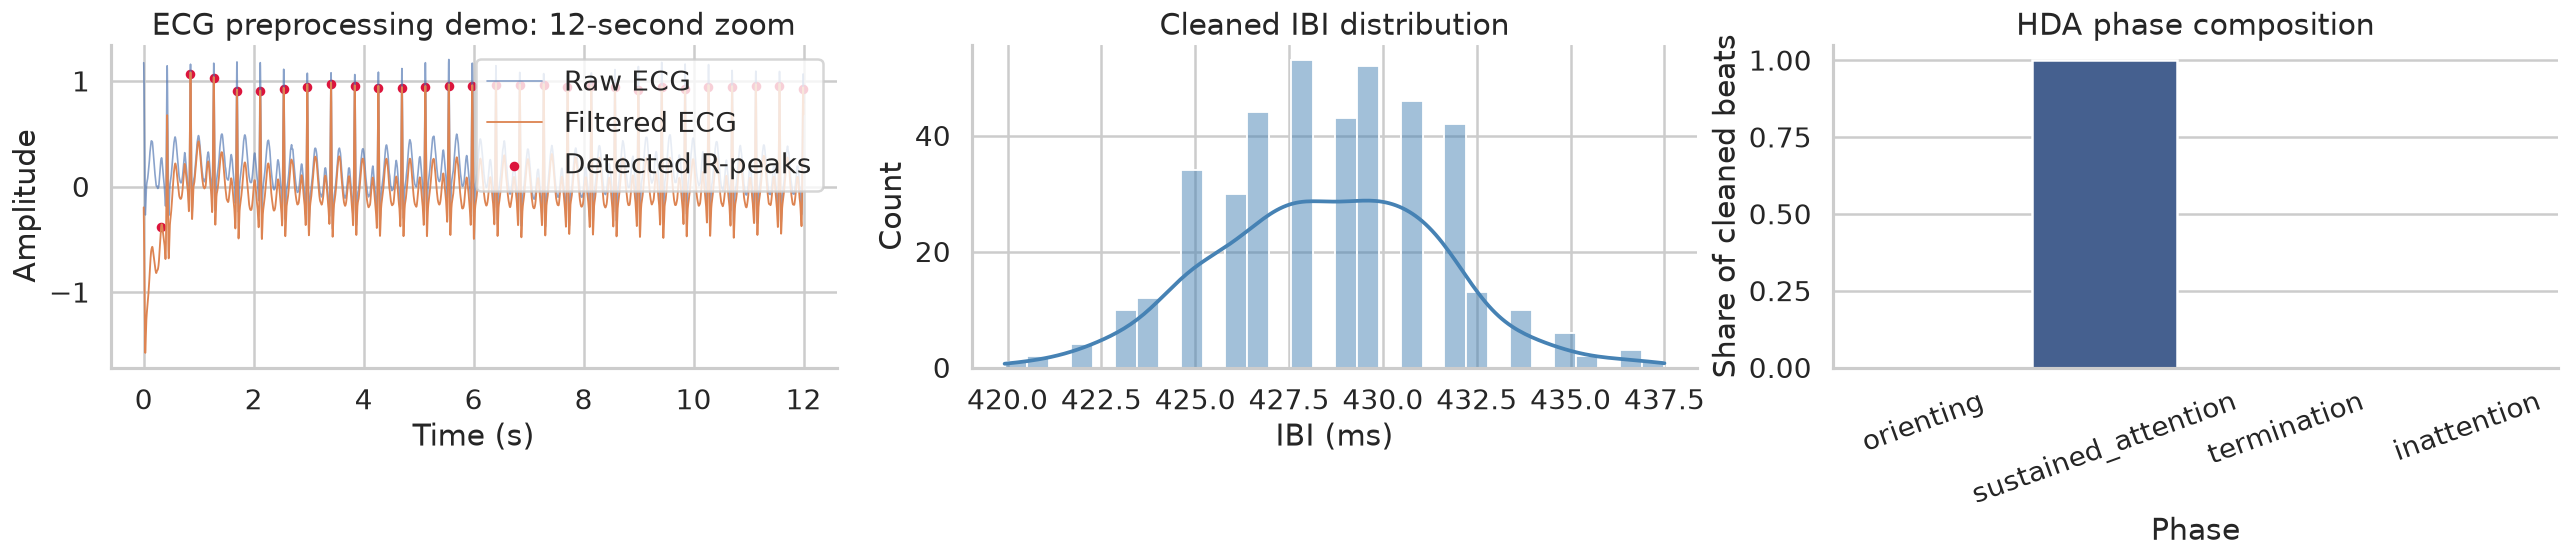

,hda_pct_inattention,hda_pct_orienting,hda_pct_sustained_attention,hda_pct_termination,pc_sd1,pc_sd1_sd2_ratio,pc_sd2,rsa_cwt_power,sampen,td_cvnn,td_hti,td_mean_ibi,td_rmssd,td_sdnn
value,0.0,0.0,1.0,0.0,1.3469,0.3404,3.9569,87.8151,1.477,0.0069,7.6981,428.5075,1.9027,2.964


In [4]:
sampling_rate = int(study_cfg.get("ecg", {}).get("sampling_rate_hz", 1024))
time_s, raw_signal = simulate_ecg_signal(duration_seconds=180, sampling_rate=sampling_rate, heart_rate=140, seed=42)
filtered_signal = bandpass_filter(raw_signal, sampling_rate=sampling_rate)
rpeaks = detect_rpeaks(filtered_signal, sampling_rate=sampling_rate)
cleaned_ibi_df = preprocess_ecg_pipeline(
    raw_signal,
    sampling_rate=sampling_rate,
    threshold_sd=study_cfg.get("ecg", {}).get("artifact_threshold_sd", 3.5),
)

timestamps_ms = np.cumsum(cleaned_ibi_df["ibi_ms"].to_numpy())
exemplar_features = extract_all_hrv_features(cleaned_ibi_df["ibi_ms"].to_numpy(), timestamps_ms=timestamps_ms)
hda_df = identify_hda_phases(cleaned_ibi_df["ibi_ms"].to_numpy(), timestamps_ms)
feature_preview = pd.Series(exemplar_features, name="value").sort_index().to_frame()

peak_times = rpeaks / sampling_rate
zoom_mask = time_s <= 12
peak_mask = peak_times <= 12
phase_share = hda_df["phase"].value_counts(normalize=True).reindex(
    ["orienting", "sustained_attention", "termination", "inattention"],
    fill_value=0,
)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
axes[0].plot(time_s[zoom_mask], raw_signal[zoom_mask], label="Raw ECG", linewidth=1.0, alpha=0.65)
axes[0].plot(time_s[zoom_mask], filtered_signal[zoom_mask], label="Filtered ECG", linewidth=1.1)
axes[0].scatter(peak_times[peak_mask], filtered_signal[rpeaks[peak_mask]], color="crimson", s=18, label="Detected R-peaks")
axes[0].set_title("ECG preprocessing demo: 12-second zoom")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="upper right")

sns.histplot(cleaned_ibi_df["ibi_ms"], bins=30, kde=True, color="steelblue", ax=axes[1])
axes[1].set_title("Cleaned IBI distribution")
axes[1].set_xlabel("IBI (ms)")
axes[1].set_ylabel("Count")

sns.barplot(x=phase_share.index, y=phase_share.values, palette="mako", ax=axes[2])
axes[2].set_title("HDA phase composition")
axes[2].set_xlabel("Phase")
axes[2].set_ylabel("Share of cleaned beats")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

feature_preview.T.round(4)

## 3. Participant summaries, imputation, and predictive modeling
The final analytical layer needs both longitudinal context and participant-level summaries. In this notebook, the participant table is built from:

- baseline demographic and morbidity covariates
- terminal or last-observed physiological features
- trajectory slopes from the repository's trajectory helper
- 36-month ADOS-based risk labels for prediction

The cell below then:

1. derives trajectory features
2. documents and performs MICE-style imputation for numeric predictors
3. builds descriptive trajectory and correlation views
4. compares predictive models for ASD-risk classification
5. exports aggregate tables for downstream reporting

2026-06-13 18:43:15 | src.feature_engineering.trajectory_features | INFO | extract_trajectory_features: 27 trajectory features from 3 input features.
2026-06-13 18:43:15 | src.feature_engineering.trajectory_features | INFO | extract_trajectory_features: 27 trajectory features from 3 input features.
2026-06-13 18:43:15 | src.feature_engineering.trajectory_features | INFO | extract_trajectory_features: 27 trajectory features from 3 input features.
2026-06-13 18:43:15 | src.feature_engineering.trajectory_features | INFO | extract_trajectory_features: 27 trajectory features from 3 input features.
2026-06-13 18:43:15 | src.feature_engineering.trajectory_features | INFO | extract_trajectory_features: 27 trajectory features from 3 input features.
2026-06-13 18:43:16 | src.feature_engineering.trajectory_features | INFO | extract_trajectory_features: 27 trajectory features from 3 input features.
2026-06-13 18:43:16 | src.feature_engineering.trajectory_features | INFO | extract_trajectory_featur

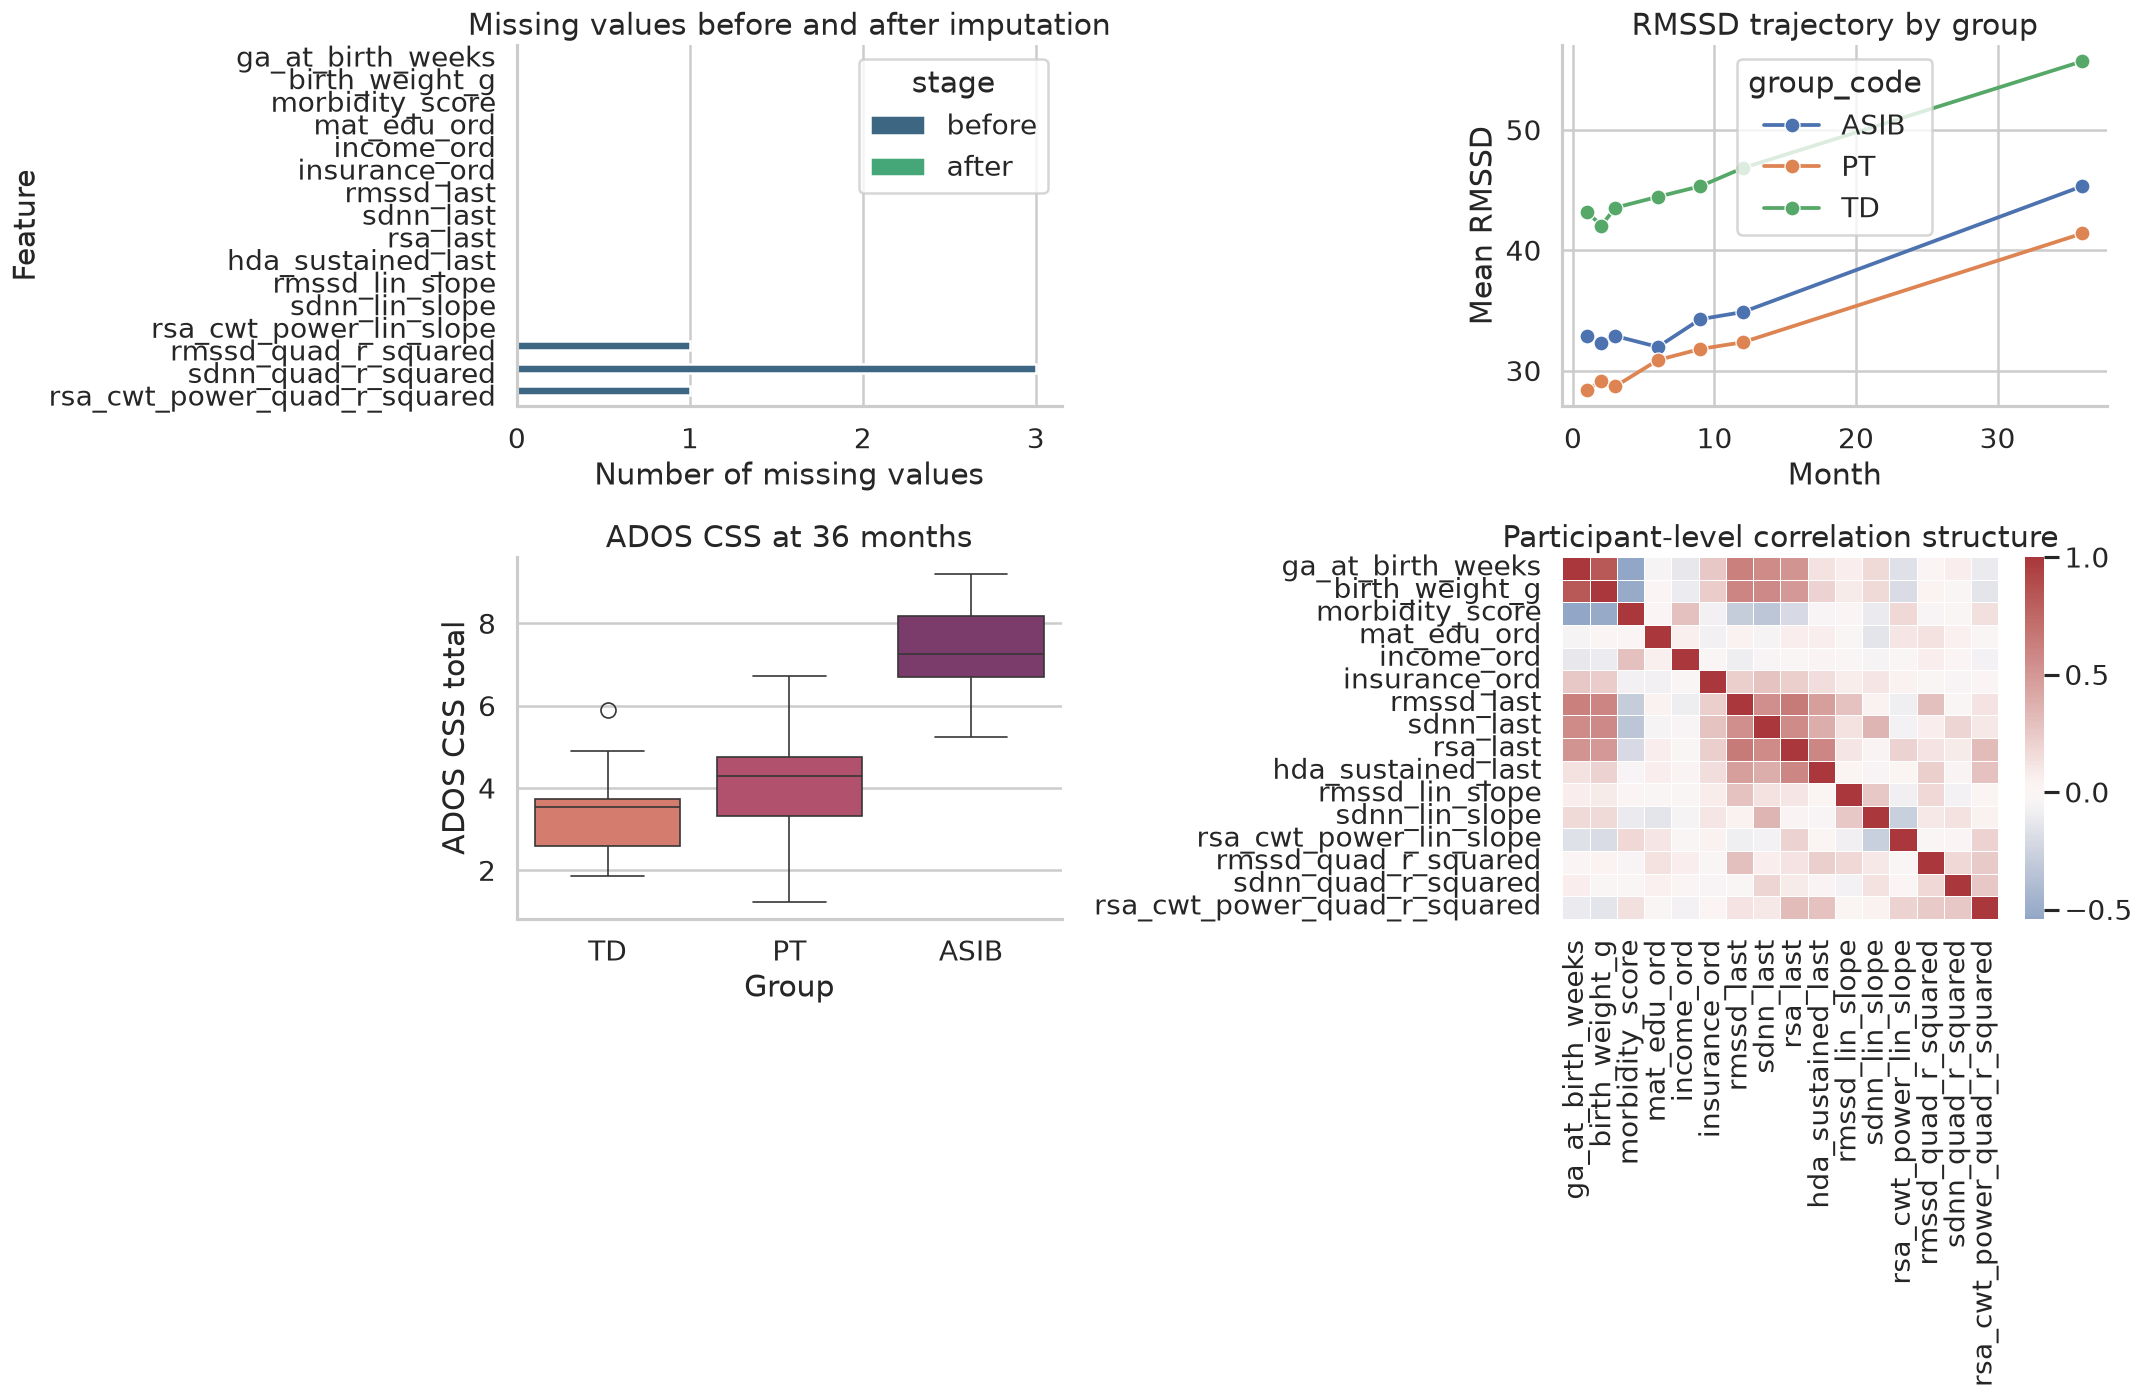

2026-06-13 18:43:26 | src.models.ml_pipeline | INFO | build_pipeline: built 'logistic_regression' pipeline.
2026-06-13 18:44:49 | src.models.ml_pipeline | INFO | build_pipeline: built 'random_forest' pipeline.
2026-06-13 18:45:15 | src.models.model_evaluation | INFO | compare_models: comparing 2 models.
2026-06-13 18:45:15 | src.models.ml_pipeline | INFO | build_pipeline: built 'logistic_regression' pipeline.
2026-06-13 18:45:29 | src.models.ml_pipeline | INFO | train_and_evaluate: roc_auc = 0.8483 ± 0.1582 over 5 folds.
2026-06-13 18:45:33 | src.models.ml_pipeline | INFO | build_pipeline: built 'logistic_regression' pipeline.
2026-06-13 18:45:47 | src.models.ml_pipeline | WARNING | run_subgroup_analysis: skipping subgroup 'PT' (n=59).
2026-06-13 18:45:47 | src.models.ml_pipeline | WARNING | run_subgroup_analysis: skipping subgroup 'TD' (n=29).


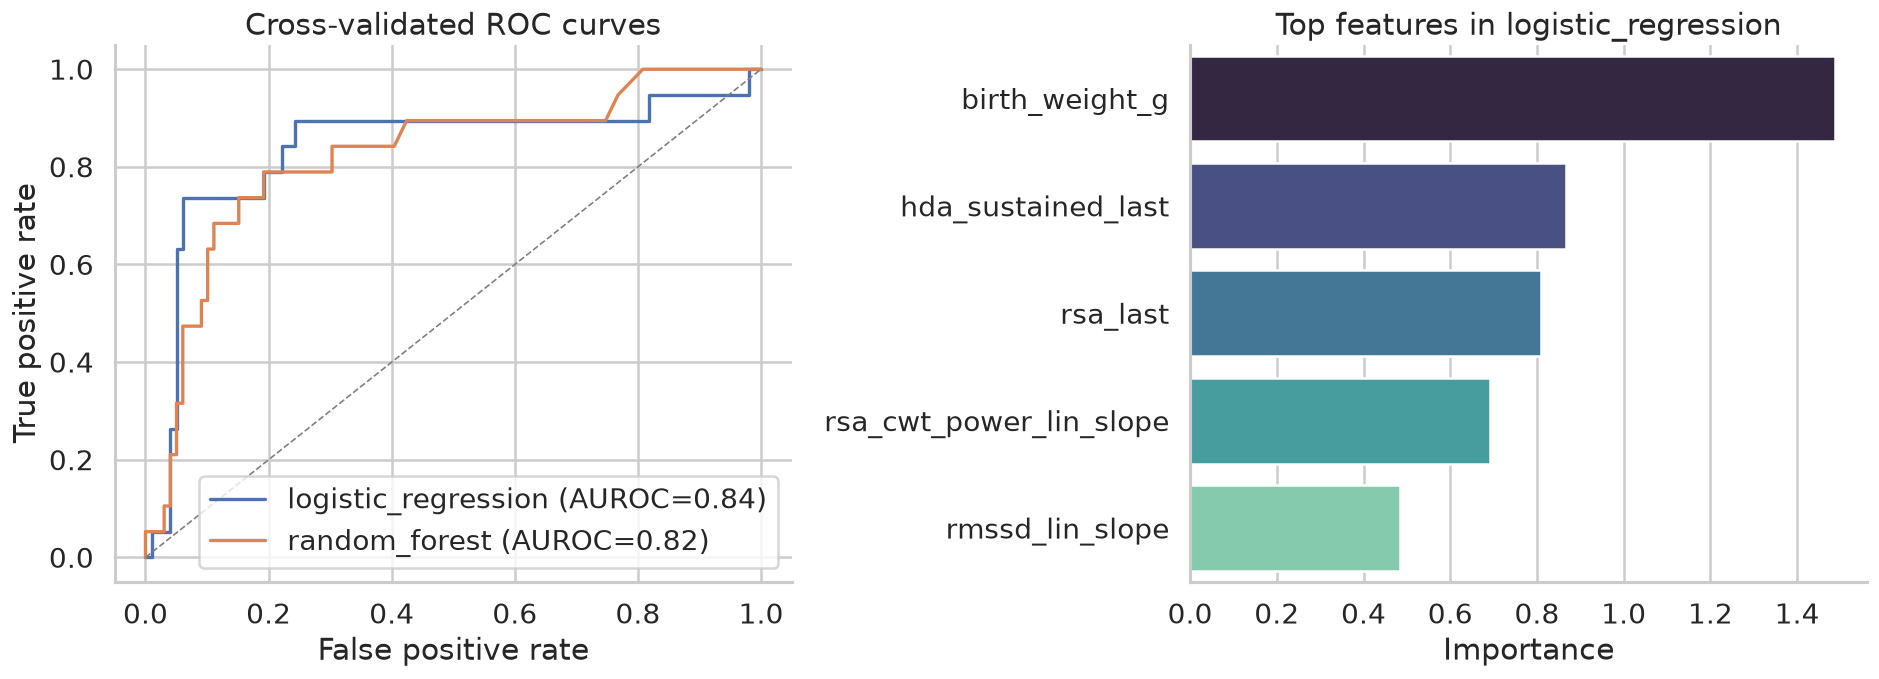

Best model: logistic_regression
Cross-validated AUROC mean: 0.848 +/- 0.158
Top MAR indicators for rmssd_last:


ga_at_birth_weeks    1.0
birth_weight_g       1.0
morbidity_score      1.0
mat_edu_ord          1.0
income_ord           1.0
insurance_ord        1.0
sdnn_last            1.0
rsa_last             1.0
Name: p_value, dtype: float64

,group_code,n,ga_mean,ga_sd,birth_weight_mean,morbidity_mean
0,ASIB,45,28.31,1.88,1196.58,2.00
1,PT,90,28.59,2.22,1223.68,1.87
2,TD,42,38.65,2.20,3190.81,0.07


In [5]:
trajectory_rows = []
for participant_id, participant_df in analysis_long.groupby("participant_id"):
    trajectory = extract_trajectory_features(participant_df, ["rmssd", "sdnn", "rsa_cwt_power"], time_col="month")
    trajectory["participant_id"] = participant_id
    trajectory_rows.append(trajectory)
trajectory_df = pd.DataFrame(trajectory_rows)

participant_summary = (
    analysis_long.groupby("participant_id")
    .apply(summarize_participant)
    .reset_index()
    .merge(trajectory_df, on="participant_id", how="left")
)

candidate_numeric_cols = [
    "ga_at_birth_weeks",
    "birth_weight_g",
    "morbidity_score",
    "mat_edu_ord",
    "income_ord",
    "insurance_ord",
    "rmssd_last",
    "sdnn_last",
    "rsa_last",
    "hda_sustained_last",
    "rmssd_lin_slope",
    "sdnn_lin_slope",
    "rsa_cwt_power_lin_slope",
    "rmssd_quad_r_squared",
    "sdnn_quad_r_squared",
    "rsa_cwt_power_quad_r_squared",
]
candidate_numeric_cols = [
    column for column in candidate_numeric_cols
    if column in participant_summary.columns and participant_summary[column].notna().sum() >= 10
]

imputation_input = participant_summary[candidate_numeric_cols].copy()
report_path = repo_root / "reports" / "data_quality" / "master_notebook_imputation_report.txt"
imputation_report = document_imputation_assumptions(imputation_input, output_path=report_path)

participant_summary_imputed = participant_summary.copy()
participant_summary_imputed[candidate_numeric_cols] = impute_with_mice(imputation_input)
missing_before_after = pd.DataFrame({
    "before": participant_summary[candidate_numeric_cols].isna().sum(),
    "after": participant_summary_imputed[candidate_numeric_cols].isna().sum(),
})
mar_snapshot = assess_missingness_mechanism(imputation_input, target_col="rmssd_last") if "rmssd_last" in imputation_input.columns else {}

baseline_summary = (
    analysis_long.loc[analysis_long["event"] == "nicu_admission"]
    .groupby("group_code")
    .agg(
        n=("participant_id", "nunique"),
        ga_mean=("ga_at_birth_weeks", "mean"),
        ga_sd=("ga_at_birth_weeks", "std"),
        birth_weight_mean=("birth_weight_g", "mean"),
        morbidity_mean=("morbidity_score", "mean"),
    )
    .round(2)
    .reset_index()
)

trajectory_summary = (
    analysis_long.groupby(["group_code", "month"])[["rmssd", "sdnn", "rsa_cwt_power"]]
    .mean()
    .reset_index()
)
month_36_frame = analysis_long.loc[analysis_long["event"] == "month_36", ["group_code", "ados2_css_total"]].dropna()
correlation_frame = participant_summary_imputed[candidate_numeric_cols].corr()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
missing_plot = missing_before_after.reset_index().rename(columns={"index": "feature"}).melt(id_vars="feature", var_name="stage", value_name="n_missing")
sns.barplot(data=missing_plot, x="n_missing", y="feature", hue="stage", palette="viridis", ax=axes[0, 0])
axes[0, 0].set_title("Missing values before and after imputation")
axes[0, 0].set_xlabel("Number of missing values")
axes[0, 0].set_ylabel("Feature")

sns.lineplot(data=trajectory_summary, x="month", y="rmssd", hue="group_code", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("RMSSD trajectory by group")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Mean RMSSD")

sns.boxplot(data=month_36_frame, x="group_code", y="ados2_css_total", palette="flare", ax=axes[1, 0])
axes[1, 0].set_title("ADOS CSS at 36 months")
axes[1, 0].set_xlabel("Group")
axes[1, 0].set_ylabel("ADOS CSS total")

sns.heatmap(correlation_frame, cmap="vlag", center=0, linewidths=0.3, ax=axes[1, 1])
axes[1, 1].set_title("Participant-level correlation structure")

plt.tight_layout()
plt.show()

model_frame = participant_summary_imputed.dropna(subset=["asd_risk_flag"]).copy()
feature_columns = [
    "ga_at_birth_weeks",
    "birth_weight_g",
    "morbidity_score",
    "mat_edu_ord",
    "income_ord",
    "insurance_ord",
    "rmssd_last",
    "sdnn_last",
    "rsa_last",
    "hda_sustained_last",
    "rmssd_lin_slope",
    "sdnn_lin_slope",
    "rsa_cwt_power_lin_slope",
]
feature_columns = [column for column in feature_columns if column in model_frame.columns]
X_model = model_frame[feature_columns].fillna(model_frame[feature_columns].median())
y_model = model_frame["asd_risk_flag"].astype(int)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_names = ["logistic_regression", "random_forest"]
results = {}
roc_payload = {}

for model_name in model_names:
    pipeline = build_pipeline(model_name)
    probabilities = cross_val_predict(pipeline, X_model, y_model, cv=cv, method="predict_proba")[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    metrics = compute_classification_metrics(y_model, predictions, probabilities)
    ci = bootstrap_ci(
        compute_classification_metrics,
        y_model.to_numpy(),
        predictions,
        y_prob=probabilities,
        n_samples=300,
        random_state=42,
    )
    if "auroc" in ci:
        metrics["auroc_ci"] = f"{ci['auroc']['lower']:.3f}-{ci['auroc']['upper']:.3f}"
    else:
        metrics["auroc_ci"] = "n/a"
    results[model_name] = metrics
    roc_payload[model_name] = roc_curve(y_model, probabilities)

comparison_df = compare_models(results)
best_model_name = comparison_df.iloc[0]["model"]
best_pipeline = build_pipeline(best_model_name)
best_cv_summary = train_and_evaluate(X_model, y_model, best_pipeline, cv_folds=5)
importance_df = get_feature_importance(best_cv_summary["fitted_pipeline"], feature_columns).head(10)
subgroup_df = run_subgroup_analysis(
    pd.concat([X_model, model_frame[["group_code"]]], axis=1),
    y_model,
    build_pipeline(best_model_name),
    subgroup_col="group_code",
    subgroup_values=sorted(model_frame["group_code"].dropna().unique().tolist()),
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for model_name, roc_result in roc_payload.items():
    fpr, tpr, _ = roc_result
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUROC={results[model_name]['auroc']:.2f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
axes[0].set_title("Cross-validated ROC curves")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()

sns.barplot(data=importance_df, y="feature", x="importance", palette="mako", ax=axes[1])
axes[1].set_title(f"Top features in {best_model_name}")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

tables_dir = repo_root / "reports" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)
baseline_summary.to_csv(tables_dir / "master_notebook_baseline_summary.csv", index=False)
comparison_df.to_csv(tables_dir / "master_notebook_model_comparison.csv", index=False)
importance_df.to_csv(tables_dir / "master_notebook_feature_importance.csv", index=False)
subgroup_df.to_csv(tables_dir / "master_notebook_subgroup_performance.csv", index=False)

print("Best model:", best_model_name)
print(f"Cross-validated AUROC mean: {best_cv_summary['mean_score']:.3f} +/- {best_cv_summary['std_score']:.3f}")
print("Top MAR indicators for rmssd_last:")
display(pd.Series(mar_snapshot, name="p_value").sort_values().head(8))

baseline_summary

## 4. Notebook usage notes
This notebook is designed to remain useful in two modes:

- **Secure-data mode**: when `NANO_DATA_ROOT` is configured and the processed parquet files exist, the notebook reads the repository's live inputs.
- **Repository-only mode**: when those secure files are unavailable, the notebook switches to a synthetic fallback that preserves the same longitudinal structure and analysis contract.

That design keeps the artifact reviewable, rerunnable, and safe to store in version control while still mirroring the real project pipeline.